# Exercise 1: Calculate pressure and fluid composition from melt and fluid inclusion data

In this exercise we will calculate pressures and fluid compositions from melt inclusion (MI) and fluid inclusion (FI) data from the 2018 Lower East Rift Zone eruption of Kı̄lauea (Wieser et al., 2021; DeVitre & Wieser, 2024) using the tools VESIcal (Iacovino et al., 2021), DiadFit (Wieser & DeVitre, 2024), VolFe (Hughes et al., 2025), and Thermobar (Wieser et al., 2022b) through the VICTOR platform (Lev et al., 2025). Other tools are available for these types of calculations (e.g., Solwcad - Papale et al. 2006; M2Fluid - Sun and Yao 2026) but we have chosen options available entirely through VICTOR.

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b>🐣 &nbsp; To run locally</b><br> See the notebook <b><a href="0_Getting_Started.ipynb">0. Getting Started</a></b>. Always remember to ensure this notebook is running in the volatiles-gs-workshop26 conda environment!

<em>If you are running this on the VICTOR platform, all packages are already installed and you can skip this step. More information on VICTOR can be found at <a href="https://docs.victorproject.org/en/latest/index.html">https://docs.victorproject.org/en/latest/index.html</em></a>
</div>

## 1. Introduction
### 1.1 Import packages and note versions

In [7]:
# Packages that we will use in our code always get imported before we need them.
# This is canonically done at the top of a script.
# ⚠️ Note that this can take a few seconds if it's the first time you're importing these libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import VolFe as vf
import VESIcal as vc
import Thermobar as tb
import DiadFit as pf

import os
os.makedirs("output", exist_ok=True) # creates the output folder

When reporting calculations in manuscripts, it's important to know which version of the Python package the results you are showing used - so we can output those below. This notebook was created using VolFe: 1.0.3, VESIcal: 1.2.12, Thermobar: 1.0.72, and DiadFit: 1.0.23.

In [8]:
print(
    f"VolFe: {vf.__version__}",
    f"\nVESIcal: {vc.__version__}",
    f"\nThermobar: {tb.__version__}",
    f"\nDiadFit: {pf.__version__}",
    )

VolFe: 1.0.3 
VESIcal: 1.2.12 
Thermobar: 1.0.72 
DiadFit: 1.0.23


### 1.2 Import data

Typically, you'll have a spreadsheet full of MI and/or FI analyses to process. In this case, we've created simplified xlsx file derived from the spreadsheets provided in Supplementary Materials of the original papers (i.e., some columns and rows have been deleted to make them easier to use). MI and MG data are from Wieser et al. (2021), whilst FI data is from DeVitre & Wieser (2024).

In [9]:
df_MI = pd.read_excel("data/Kilauea_MI_FI_MG_data.xlsx", sheet_name='MI_Data') # creates a DataFrame of just data in the MI_Data sheet of the excel spreadsheet
df_MG = pd.read_excel("data/Kilauea_MI_FI_MG_data.xlsx", sheet_name='MG_data') # ... as above for the MG_Data sheet
df_FI = pd.read_excel("data/Kilauea_MI_FI_MG_data.xlsx", sheet_name='FI_Data') # ... and the FI_Data sheet

We can plot the data to see how it looks - like the H<sub>2</sub>O and CO<sub>2</sub> content of melt inclusions and matrix glass.

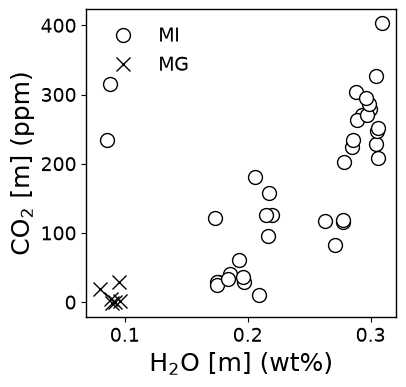

In [10]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4,4)) # creates a one panel figure using matplotlib

# MI: open circles - labels it MI for the legend
ax1.plot(df_MI['H2O'], df_MI['CO2_ppm'], 'ok', mfc='white', label = "MI")
# MG: x symbols - labels it MG for the legend
ax1.plot(df_MG['H2O'], df_MG['CO2_ppm'], 'xk', label="MG")

ax1.set_xlabel('H$_2$O [m] (wt%)') # labels the x-axis
ax1.set_ylabel('CO$_2$ [m] (ppm)') # labels the y-axis
ax1.legend(frameon=False) # adds a legend

H<sub>2</sub>O contents of melt inclusions commonly show signs of "resetting", wherein dissolved H<sub>2</sub>O concentrations are <em>lower</em> than those at the time of entrapment due to diffusive requilibration throught the crystal host during crustal magma storage (Wieser et al. 2021). For this exercise, we set the MI H<sub>2</sub>O contents to 0.5 wt% as in Wieser et al. (2021).

In [11]:
for row in range(0,len(df_MI),1):
    df_MI.loc[row,'H2O'] = 0.5

## 2. Calculate temperature using Thermobar

A temperature is requied to calculate pressures and fluid compositions from MI/MG data. 

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🌡️ &nbsp; Thermobar </b> is an open-source python3 tool for performing mineral and mineral-melt thermobarometry, hygrometry and chemometry.

More information on Thermobar can be found at https://thermobar.readthedocs.io/en/latest/

</div>

Thermobar has a huge variety of thermometers available to choose from. Run the next cell to see the options available in Thermobar just for liquid-only thermometers.

In [12]:
help(tb.calculate_liq_only_temp)

Help on function calculate_liq_only_temp in module Thermobar.liquid_thermometers:

calculate_liq_only_temp(
    *,
    liq_comps,
    equationT,
    P=None,
    H2O_Liq=None,
    print=False
)
     Liquid-only thermometery. Returns a temperature in Kelvin.

    Parameters
     -------

     liq_comps: pandas.DataFrame
         liquid compositions with column headings SiO2_Liq, MgO_Liq etc.

     equationT: str
         If has _sat at the end, represents the saturation surface of that mineral.

         Equations from Putirka et al. (2016).
             | T_Put2016_eq3_amp_sat (saturation surface of amphibole)

         Equations from Putirka (2008) and older studies:

             | T_Put2008_eq13
             | T_Put2008_eq14
             | T_Put2008_eq15
             | T_Put2008_eq16
             | T_Put2008_eq34_cpx_sat
             | T_Put1999_cpx_sat
             * Following 3 thermometers are adaptations of olivine-liquid thermometers with  DMg calculated using Beattie 1993,
    

Following Wieser et al. (2021), we calculate the temperature using the MgO-liquid thermometer of Helz & Thornber (1987) implemented in Thermobar. 

Thermobar requires specific column names to recognise what each column contains - so first we'll need to rename the columns to be compatible with Thermobar. Thermobar also assumes the composition is in wt%, so anything that isn't would need to be converted. Then we can run the calculation and add the results to the original dataframe!

In [13]:
# renames column names to be compatible with Thermobar
MI_tb=df_MI.copy()
MI_tb = MI_tb.rename(columns = {"SiO2":"SiO2_Liq","TiO2":"TiO2_Liq","Al2O3":"Al2O3_Liq", 
                             "MnO":"MnO_Liq","MgO":"MgO_Liq","CaO":"CaO_Liq",
                             "Na2O":"Na2O_Liq","K2O":"K2O_Liq","P2O5":"P2O5_Liq","H2O":"H2O_Liq"})

# and add a FeOt column
MI_tb['FeOt_Liq']=MI_tb['FeO']+MI_tb['Fe2O3']*0.8998
                             
# calculate temperature in celcius (hence -273.15) using MgO-Lq thermometer of Helz & Thornber (1987) using Thermobar
T_C_MI = tb.calculate_liq_only_temp(liq_comps=MI_tb, equationT="T_Helz1987_MgO")-273.15

# adds temperatures to original dataframe
if "T_C" not in df_MI.columns:
    df_MI.insert(1,"T_C",T_C_MI)

# save your results
df_MI.to_csv("output/wieser2021_w_temperatures.csv")

We can plot the MgO content against the temperature to see the correlation.

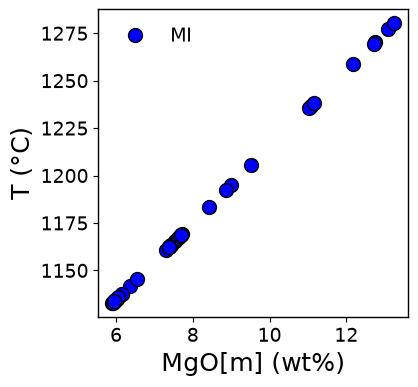

In [14]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4,4))


ax1.plot(df_MI['MgO'], df_MI['T_C'], 'ok', mfc='blue', label="MI")

ax1.set_xlabel('MgO[m] (wt%)')
ax1.set_ylabel('T (°C)')
ax1.legend(frameon=False)

## 3. Calculate saturation pressures and equilibrium fluid compositions from MI data using various tools

For a particular major/minor element composition, temperature, and volatile content (partcuarly H<sub>2</sub>O and CO<sub>2</sub>) of the melt, there is a unique pressure at which the melt will be vapor saturated, called the pressure of vapor saturation, and the coexisting fluid will have a unique composition (see Hughes et al., 2024 for more details). This is often applied to MI data to calculate pressures of magma storage or submarine matrix glass (MG) data to estimate eruption pressures, which in both cases can be converted to depths given overburden density. The fluid composition is sometimes used to estimate the composition of MI-hosted bubbles to reconstruct MI compositions at entrapment. 

### 3.1 VESIcal

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; VESIcal </b> is a framework for thermodynamic modeling of magmatic volatiles written in Python - an open-source volatile solubility engine.

More information on VESIcal can be found at https://vesical.readthedocs.io/en/latest/

</div>

We can now calculate the pressure of vapor saturation and fluid composition using one of several H<sub>2</sub>O, CO<sub>2</sub>, or mixed H<sub>2</sub>O-CO<sub>2</sub> solubility models in VESIcal. All VESIcal models assume the fluid and melt only contain oxidised C-O-H-bearing species CO<sub>2</sub> and H<sub>2</sub>O. 

There are multiple model options available in VESIcal for the H<sub>2</sub>O and CO<sub>2</sub> solubility. Run the cell below to list the models available. In any VESIcal calculation call, use the argument ``model="your-model-of-interest"``, which we will demonstrate below.

In [15]:
vc.get_model_names()

['ShishkinaIdealMixing',
 'Dixon',
 'IaconoMarziano',
 'Liu',
 'ShishkinaCarbon',
 'ShishkinaWater',
 'DixonCarbon',
 'DixonWater',
 'IaconoMarzianoCarbon',
 'IaconoMarzianoWater',
 'AllisonCarbon',
 'AllisonCarbon_sunset',
 'AllisonCarbon_sfvf',
 'AllisonCarbon_erebus',
 'AllisonCarbon_vesuvius',
 'AllisonCarbon_etna',
 'AllisonCarbon_stromboli',
 'MooreWater',
 'LiuWater',
 'LiuCarbon']

Here we'll use the model of Iacono-Marziano et al. (2021) ``"IaconoMarziano"``.

Note that how the melt composition is normalised is important for the results and different H<sub>2</sub>O-CO<sub>2</sub> models use different normalisation routines (further explanations can be found in Iacovino et al., 2021, and Wieser et al., 2021a). ``"IaconoMarziano"`` uses the ``"additionalvolatile"`` normalisation routine, whereby the anhydrous melt composition is normalised to 100 wt%; CO<sub>2</sub> and H<sub>2</sub>O are added on top (i.e., the sum is greater than 100 wt%); and then everything is renormalised to 100 wt%.

Now we can run VESIcal using our chosen H<sub>2</sub>O-CO<sub>2</sub> model. As with Thermobar, VESIcal requires specific (but different) column headers to understand the input data. This is why we changed the column headers in the notebook rather than in the spreadsheet. Also, CO<sub>2</sub> needs to be in wt% not ppm, so we convert it. Then we use the ``calculate_equilibrium_fluid_comp`` function to calculate both pressure and fluid composition.

In [16]:
rename_dict = {"Sample Name": "Label"} # renames the Sample Name column as Label

MI_vc = df_MI.copy()
MI_vc = MI_vc.rename(columns=rename_dict)
MI_vc.index.name = "Label"

MI_vc_bf = vc.BatchFile(filename=None, dataframe=MI_vc)
results_pvsat_vc = MI_vc_bf.calculate_equilibrium_fluid_comp(temperature='T_C', # We have to tell VESIcal which column is temperature
                                                             model="IaconoMarziano")

# save your results
results_pvsat_vc.to_csv("output/results_pvsat_vc.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_pvsat_vc

And we plot to see how the melt volatile content changes with the calculated pressure and what the fluid composition is doing as well!

In [ ]:
# if you haven't run this Exercise , you can grab the "answer key" file from here:
#results_pvsat_vc = pd.read_csv("files/results_pvsat_vc.csv")

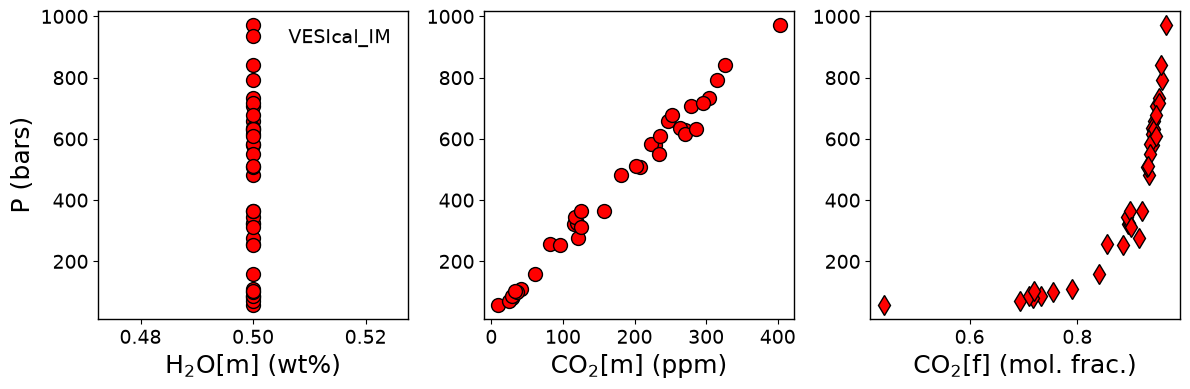

In [17]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4)) # figure with three panels in a row

df = results_pvsat_vc # choose the VESIcal results to plot

# plot VESIcal results in red
ax1.plot(df['H2O'], df['SaturationP_bars_VESIcal'], 'ok', mfc='red', label = "VESIcal_IM")
ax2.plot(df['CO2']*10000, df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'], df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

# label the axes
ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H$_2$O[m] (wt%)')
ax2.set_xlabel('CO$_2$[m] (ppm)')
ax3.set_xlabel('CO$_2$[f] (mol. frac.)')

# add a legend
ax1.legend(frameon=False)

plt.tight_layout()

### 3.3 VolFe

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; VolFe </b> is an open-source Python package for calculating melt-vapor equilibra in the CHOS+ system, including concentration, speciation, and isotope ratios.

More information on VolFe can be found at https://volfe.readthedocs.io/en/latest/

</div>

We can also calculate the pressure of vapor saturation and fluid composition using VolFe, which assumes the fluid and melt contain a variety of reduced and oxidised C-O-H-S-bearing species. This needs additional information, such as some estimate of an oxygen fugacity related variable (e.g., <i>f</i>O<sub>2</sub>, ΔFMQ, ΔNNO, Fe<sup>3+</sup>/Fe<sub>T</sub>, or S<sup>6+</sup>/S<sub>T</sub>). We'll use a value of ΔFMQ+0.2 for all MI and MG, which is within the range described in Wieser et al. (2021), but in other examples this can be specified for each composition individually.

There are lots of different options available in VolFe. Similar to VESIcal, there are different H<sub>2</sub>O and CO<sub>2</sub> solubility models, but there are also different sulfide and sulfate solubility models and relationships between Fe<sup>3+</sup>/Fe<sub>T</sub> and <i>f</i>O<sub>2</sub> to choose from. 

Run the cell below to see all the parameters that can be changed in VolFe or head to the VolFe ReadTheDocs: https://volfe.readthedocs.io/en/latest/current_mdv.html

In [18]:
help(vf.make_df_and_add_model_defaults)

Help on function make_df_and_add_model_defaults in module VolFe.model_dependent_variables:

make_df_and_add_model_defaults(models)
    Converts user-provided model configurations (e.g. ['carbon dioxide','MORB_Dixon95'],
    ['hydrogen sulfide','basaltic andesite'] into a structured pandas DataFrame,
    combined with default options for anything not specified.


    Parameters
    ----------
    models : list of [str, str]
        Each inner list contains two elements: the model type (str) and the
        user-specified option (str) for that model type.

    Returns
    -------
    pandas.DataFrame
        Index of 'type' and  column of 'option', containing the user-specified option or
        the default option if none is provided.


    Model Parameters and Options
    ----------------------------
    The following parameters can be overridden in models.


    ### Specifying species ###

    COH_species: Specifying what COH species are present in the melt and vapor.
        - 'yes_H2

Here we'll focus on the H<sub>2</sub>O, CO<sub>2</sub>, sulfide, and sulfate solubility options:

In [19]:
# H2O solubility model
help(vf.C_H2O)

Help on function C_H2O in module VolFe.model_dependent_variables:

C_H2O(
    PT,
    melt_wf,
    models=                            option
type                              
COH_species     yes_H2_CO_CH4_melt
H2S_m                         True
species X                       Ar
Hspeciation                   none
fO2                       Kress91A
...                            ...
error                          0.1
print status                 False
output csv                    True
setup                        False
high precision               False

[78 rows x 1 columns]
)
    Solubility constant for disolving H2O in the melt.

    Parameters
    ----------
    PT: dict
        Pressure (bars) as "P" and temperature ('C) as "T".

    melt_wf: dict
        Melt composition (SiO2, TiO2, etc.), not normally used unless model option
        requires melt composition.

    models: pandas.DataFrame
        Minimum requirement is indexes of "Hspeciation" and "water" and column label of


In [20]:
# CO2 solubility model
help(vf.C_CO3)

Help on function C_CO3 in module VolFe.model_dependent_variables:

C_CO3(
    PT,
    melt_wf,
    models=                            option
type                              
COH_species     yes_H2_CO_CH4_melt
H2S_m                         True
species X                       Ar
Hspeciation                   none
fO2                       Kress91A
...                            ...
error                          0.1
print status                 False
output csv                    True
setup                        False
high precision               False

[78 rows x 1 columns]
)
    Solubility constant for disolving CO2 as CO2,T (all oxidised carbon, i.e., CO2mol
    and CO32-, as CO2,T) in the melt: C_CO2,T = xmCO2,T/fCO2 (mole fraction/bar)


    Parameters
    ----------
    PT: dict
        Pressure (bars) as "P" and temperature ('C) as "T".

    melt_wf: dict
        Melt composition (SiO2, TiO2, etc.).

    models: pandas.DataFrame
        Minimum requirement is index of "carbon 

In [21]:
# sulfide solubility model
help(vf.C_S)

Help on function C_S in module VolFe.model_dependent_variables:

C_S(
    PT,
    melt_wf,
    models=                            option
type                              
COH_species     yes_H2_CO_CH4_melt
H2S_m                         True
species X                       Ar
Hspeciation                   none
fO2                       Kress91A
...                            ...
error                          0.1
print status                 False
output csv                    True
setup                        False
high precision               False

[78 rows x 1 columns]
)
    Solubility constant for disolving S in the melt as S2-: C_S = wmS2-*(fO2/fS2)^0.5
    (in ppmw and bar).


    Parameters
    ----------
    PT: dict
        Pressure (bars) as "P" and temperature ('C) as "T".

    melt_wf: dict
        Melt composition (SiO2, TiO2, etc.)..

    models: pandas.DataFrame
        Minimum requirement is index of "sulfide" and column label of "option".

    Returns
    -------
    

In [22]:
# sulfate solubility model
help(vf.C_SO4)

Help on function C_SO4 in module VolFe.model_dependent_variables:

C_SO4(
    PT,
    melt_wf,
    models=                            option
type                              
COH_species     yes_H2_CO_CH4_melt
H2S_m                         True
species X                       Ar
Hspeciation                   none
fO2                       Kress91A
...                            ...
error                          0.1
print status                 False
output csv                    True
setup                        False
high precision               False

[78 rows x 1 columns]
)
    Solubility constant for disolving S6+ in the melt: C_SO4 = wmS6+(fS2*fO2^3)^-0.5
    (in ppmw and bar)


    Parameters
    ----------
    PT: dict
        Pressure (bars) as "P" and temperature ('C) as "T".

    melt_wf: dict
        Melt composition (SiO2, TiO2, etc.)..

    models: pandas.DataFrame
        Minimum requirement is index of "sulfate" and column label of "option".

    Returns
    -------
  

We'll choose to use the water solubility model from Fig. S2 of Hughes et al. (2024); CO<sub>2</sub> solubility model from Dixon et al. (1995); sulfide solubility model from eq. (10.34) of O'Neill (2021); and sulfate solubility model from eq. (12a) of O'Neill & Mavrogenes (2022) - everything else will use the default options in VolFe. All options used are outputted in the results so you can check what has been used.

In [23]:
# choose the options I want - everything else will use the default options
models_vf = [['water','Basalt_Hughes24'],['carbon dioxide','MORB_Dixon95'],['sulfide','ONeill21dil'],['sulfate','ONeill22dil']]

# turn to dataframe with correct column headers and indexes    
models_vf = vf.make_df_and_add_model_defaults(models_vf)

VolFe also uses different column names... so we rename some of them...

In [24]:
MI_vf=df_MI.copy().reset_index(drop=True)

# rename the columns we need for VolFe
MI_vf = MI_vf.rename(columns={
    'CO2_ppm': 'CO2ppm',
    'S': 'STppm',
    'Sample Name':'Sample',
})

And add ΔFMQ to each row...

In [25]:
# Adds oxygen fugacity constraint to each row in the dataframe
MI_vf['DFMQ'] = 0.20

And then we run the calculations...

In [26]:
# runs the calculation
results_pvsat_vf = vf.calc_Pvsat(MI_vf, models= models_vf)

# save the results
results_pvsat_vf.to_csv("output/results_pvsat_vf.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_pvsat_vf

/srv/conda/envs/notebook/lib/python3.14/site-packages/VolFe/melt_gas.py:2059: UserWarning: you entered more than one way to infer iron speciation, note that this calcualtion is only considering the entered DFMQ
  w.warn(
/srv/conda/envs/notebook/lib/python3.14/site-packages/VolFe/melt_gas.py:2059: UserWarning: you entered more than one way to infer iron speciation, note that this calcualtion is only considering the entered DFMQ
  w.warn(
/srv/conda/envs/notebook/lib/python3.14/site-packages/VolFe/melt_gas.py:2059: UserWarning: you entered more than one way to infer iron speciation, note that this calcualtion is only considering the entered DFMQ
  w.warn(
/srv/conda/envs/notebook/lib/python3.14/site-packages/VolFe/melt_gas.py:2059: UserWarning: you entered more than one way to infer iron speciation, note that this calcualtion is only considering the entered DFMQ
  w.warn(
/srv/conda/envs/notebook/lib/python3.14/site-packages/VolFe/melt_gas.py:2059: UserWarning: you entered more than one

A warning was generated for these calculations:

``UserWarning: you entered more than one way to infer iron speciation, note that this calcualtion is only considering the entered DFMQ``

This is because the input DataFrame contains FeO, Fe<sub>2</sub>O<sub>3</sub>, and ΔFMQ, which means <i>f</i>O<sub>2</sub> is over constrained. VolFe has an order in which it will pick which <i>f</i>O<sub>2</sub> variable to use in the calculation - ΔFMQ is used in preference to FeO and Fe<sub>2</sub>O<sub>3</sub>, and the total FeO is calculated from FeO and Fe<sub>2</sub>O<sub>3</sub>.

We can then compare the VolFe results to the VESIcal results:

In [27]:
# if you haven't run this Exercise, you can grab the "answer key" file from here:
#results_pvsat_vc = pd.read_csv("files/results_pvsat_vc.csv")
#results_pvsat_vf = pd.read_csv("files/results_pvsat_vf.csv")

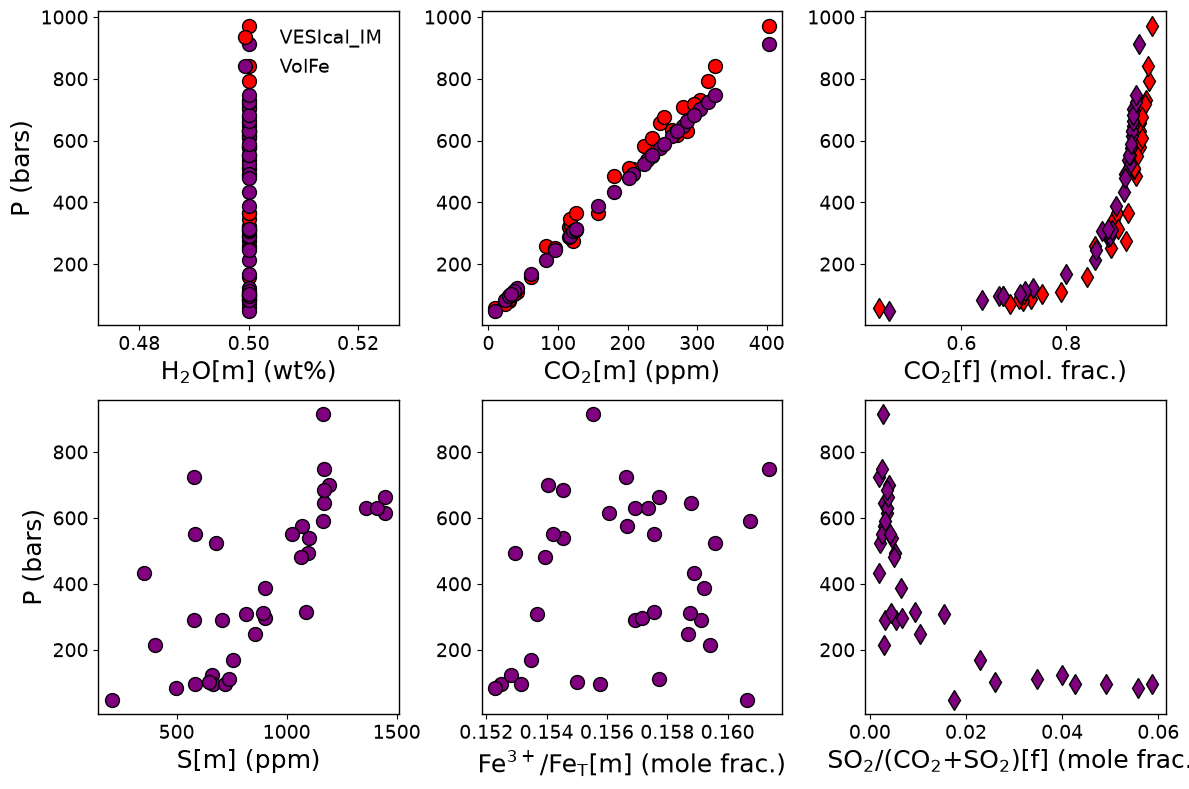

In [28]:
fig, ((ax1, ax2, ax3),(ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12,8)) # six panel figure with three columns and two rows

# vesical results in red
df = results_pvsat_vc
ax1.plot(df['H2O'], df['SaturationP_bars_VESIcal'], 'ok', mfc='red', label ="VESIcal_IM")
ax2.plot(df['CO2']*10000, df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'], df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

# volfe results in purple - not that VolFe uses different column names to VESIcal in its results
df = results_pvsat_vf
ax1.plot(df['H2OT-eq_wtpc'], df['P_bar'], 'ok', mfc='purple', label = "VolFe")
ax2.plot(df['CO2T-eq_ppmw'], df['P_bar'], 'ok', mfc='purple')
ax3.plot(df['xgCO2_mf'], df['P_bar'], 'dk', mfc='purple')
ax4.plot(df['ST_ppmw'], df['P_bar'], 'ok', mfc='purple')
ax5.plot(df['Fe3+/FeT'], df['P_bar'], 'ok', mfc='purple')
ax6.plot(df['xgSO2_mf']/(df['xgCO2_mf']+df['xgSO2_mf']), df['P_bar'], 'dk', mfc='purple')

#axes labels
ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H$_2$O[m] (wt%)')
ax2.set_xlabel('CO$_2$[m] (ppm)')
ax3.set_xlabel('CO$_2$[f] (mol. frac.)')
ax4.set_ylabel('P (bars)')
ax4.set_xlabel('S[m] (ppm)')
ax5.set_xlabel('Fe$^{3+}$/Fe$_T$[m] (mole frac.)')
ax6.set_xlabel('SO$_2$/(CO$_2$+SO$_2$)[f] (mole frac.)')

#legend
ax1.legend(frameon=False)

plt.tight_layout()

## 4. Calculate pressure from FI data using DiadFit

The density of CO<sub>2</sub> in a fluid co-existing with a melt is highly pressure-sensitive. Hence, when combined with an entrapment temperature, the CO<sub>2</sub> density can be converted to pressure using an equation of state for CO<sub>2</sub> (see Wieser et al., 2025, for more details). This is often applied to FI data to also calculate pressures of magma storage.

We will use DiadFit for these calculations.

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; DiadFit </b> is an open-source python3 tool for fitting Raman spectra.

More information on DiadFit can be found at https://diadfit.readthedocs.io/en/latest/

</div>

First, let's look at the FI density:

Text(0, 0.5, '# of analyses')

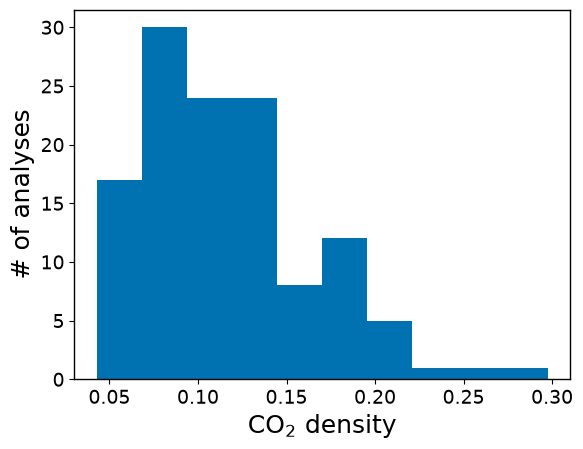

In [29]:
# create a histogram of CO2 density
plt.hist(df_FI['CO2 density (g/cm3)'])

# label axes
plt.xlabel('CO$_2$ density')
plt.ylabel('# of analyses')

DiadFit has various equations of state (EOS) built in to convert between CO<sub>2</sub> density and pressure - these options are shown below:

In [30]:
help(pf.calculate_P_for_rho_T)

Help on function calculate_P_for_rho_T in module DiadFit.CO2_EOS:

calculate_P_for_rho_T(CO2_dens_gcm3, T_K, EOS='SW96', Sample_ID=None)
    This function calculates P in kbar for a specified CO2 density in g/cm3, a known T (in K), and a specified EOS

    Parameters
    ---------------------
    CO2_dens_gcm3: int, float, pd.Series, np.array
        CO2 density in g/cm3

    T_K: int, float, pd.Series, np.array
        Temperature in Kelvin

    EOS: str
        'SW96' for Span and Wanger (1996),  'SP94' for Sterner and Pitzer (1994),
        or  'DZ06' for Pure CO2 from Duan and Zhang (2006)

    Sample_ID: str, pd.Series
        Sample ID to be appended onto output dataframe

    Returns
    --------------------
    pd.DataFrame
        Pressure in kbar, MPa and input parameters



Let's play around with how an EOS works - try changing the temperature in the cell below and see how much it matters

In [31]:
P_SP94=pf.calculate_P_for_rho_T(CO2_dens_gcm3=0.1, T_K=1300+273.15, EOS='SP94') # runs calculation
P_SP94 # displays result

,P_kbar,P_MPa,T_K,CO2_dens_gcm3
0,0.318014,31.801396,1573.15,0.1


We can calculate P for all the FI data using the EOS for Sterner and Pitzer (1994) - the temperatures in this file were calculated from Fo content of the host olivine

In [32]:
# run the calculation
results_P_df=pf.calculate_P_for_rho_T(CO2_dens_gcm3=df_FI['CO2 density (g/cm3)'], T_K=df_FI['Temperature (K)'], EOS='SP94')

# save the results
results_P_df.to_csv("output/results_P_df.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_P_df

We can now compare the pressures calculated from FI data using DiadFit to the pressures from MI data using VESIcal and VolFe

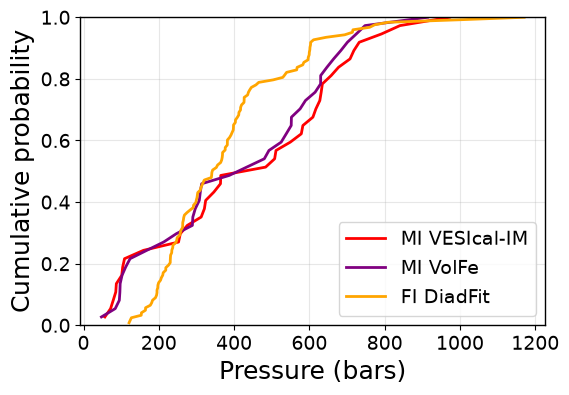

In [33]:
fig, ax = plt.subplots(figsize=(6, 4)) # single panel figure

# clean the datasets for plotting - DiadFit will be in orange
datasets = [
    (results_pvsat_vc['SaturationP_bars_VESIcal'].dropna(), 'MI VESIcal-IM', 'red'),
    (results_pvsat_vf['P_bar'].dropna(), 'MI VolFe', 'purple'),
    ((results_P_df['P_kbar'] * 1000).dropna(), 'FI DiadFit', 'orange')
]

# plot as cumulative probability
for data, label, color in datasets:
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, lw=2, label=label, color=color)

# label axes
ax.set_xlabel('Pressure (bars)')
ax.set_ylabel('Cumulative probability')

ax.set_ylim(0, 1) # set axes range
ax.legend() # add legend
ax.grid(alpha=0.3) # add grid

## 5. Comparing measured and calculated fluid composition in FI

We can also compare the measured SO<sub>2</sub>/(SO<sub>2</sub>+CO<sub>2</sub>) ratio in the FI using Raman spectroscopy to the calculated ratio for MI using VolFe.

First we calculate the SO<sub>2</sub> proportion in the FI from the relative SO<sub>2</sub>-CO<sub>2</sub> peak areas using DiadFit:

In [34]:
df_FI['SO2_Burke_table_pref']=pf.calculate_SO2_CO2_mol_prop_wave_indep(SO2_wavelength_ind=4.03, CO2_diad1_wavelength_ind=0.8, CO2_diad2_wavelength_ind=1.23, wavelength_nm=532.046,T_C=37,
                               A_SO2=df_FI['SO2_Area'], A_CO2_Tot=(df_FI['ν1_Voigt_Area']+ df_FI['2ν2_Voigt_Area']))

/tmp/ipykernel_1160/1708289270.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_FI['SO2_Burke_table_pref']=pf.calculate_SO2_CO2_mol_prop_wave_indep(SO2_wavelength_ind=4.03, CO2_diad1_wavelength_ind=0.8, CO2_diad2_wavelength_ind=1.23, wavelength_nm=532.046,T_C=37,


And plot!

In [35]:
# if you haven't run this Exercise, you can grab the "answer key" file from here:
#results_pvsat_vf = pd.read_csv("files/results_pvsat_vf.csv")

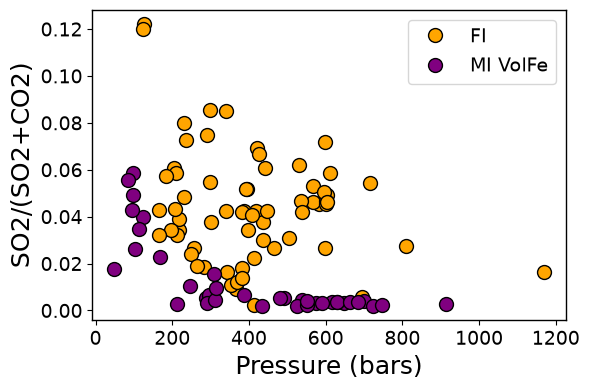

In [36]:
fig, ax = plt.subplots(figsize=(6, 4)) # single panel figure

# plot data
plt.plot(results_P_df['P_kbar']*1000, df_FI['SO2_Burke_table_pref'], 'ok', mfc='orange', label='FI')
plt.plot(results_pvsat_vf['P_bar'], results_pvsat_vf['xgSO2_mf']/(results_pvsat_vf['xgSO2_mf']+results_pvsat_vf['xgCO2_mf']), 'ok', label = 'MI VolFe', mfc='purple')

# label axes
ax.set_xlabel('Pressure (bars)')
ax.set_ylabel('SO2/(SO2+CO2)')

ax.legend() # add legend
plt.tight_layout()

## 6. Summary

In this notebook we calculated temperatures for MI data using Thermobar and pressures and fluid compositions from MI data using VESIcal and VolFe and FI data using DiadFit.

For information on how we'd cite such calculations head to <a href="3_Describing_and_Citing_Calculations.ipynb">3. Describing and citing calculations</a>, which also contains the full references for papers mentioned in this notebook.